In [4]:
import xarray as xr 
import matplotlib.pyplot as plt 
import numpy as np
import mpltern 

In [5]:
data_dir = "/Users/knv2/Documents/codebase/labeler_sweeps/phase_data"

In [6]:
ref = xr.load_dataset(data_dir+"/pm-0.0-1275.nc")
query = xr.load_dataset(data_dir+"/pm-0.0-325.nc")

In [7]:
def extract_boundaries_mpltern(domain, labels):
    """
    Extract boundary contour lines (in barycentric coordinates) for each phase
    label from a discrete ternary phase map. Uses Matplotlib's tricontour
    internally without displaying plots.

    Parameters
    ----------
    domain : (N, 3) ndarray
        Array of barycentric coordinates (t, l, r) of sampling points.
        Each row must satisfy t + l + r = 1.
    labels : (N,) ndarray
        Array of integer labels assigning a phase to each domain point.

    Returns
    -------
    boundaries : dict
        Dictionary mapping each unique phase label to a list of arrays.
        Each array has shape (M, 3) and contains the barycentric (t, l, r)
        coordinates of a contour segment (boundary) for that phase.

    Notes
    -----
    - Each phase may have multiple disconnected boundary segments, so the
      return value for a label is a list of arrays.
    - Contours are extracted at level 0 from a binary mask where the phase
      is assigned +1 and all others -1.
    - This function creates temporary Matplotlib figures internally but
      closes them immediately to avoid displaying plots.
    """
    boundaries = {}
    for phase in np.unique(labels):
        masked_codomain = np.where(labels == phase, 1.0, -1.0)

        fig, axs = plt.subplots(
            1,2, 
            figsize=(4*2, 4), 
            subplot_kw={"projection":"ternary"}
        )
        ax = axs[0]
        ax.scatter(
            domain[:,0], 
            domain[:,1], 
            domain[:,2],
            s = 5,
            color="k"
        )
        cs = ax.tricontour(
            domain[:,0], 
            domain[:,1], 
            domain[:,2],
            masked_codomain, 
            levels=[0.0],
            color = "w"
        )
        vertices = []
        for polygon in cs.allsegs[0]: # should be only single level at 0.0
            for vertex in polygon:
                coords = ax.transProjection.inverted().transform(vertex)
                vertices.append(coords)
        boundaries[str(phase)] = np.asarray(vertices).squeeze()

        ax = axs[1]
        ax.scatter(
            boundaries[str(phase)][:,0], 
            boundaries[str(phase)][:,1], 
            boundaries[str(phase)][:,2],
            s=10,
            label = phase
        )

        plt.close(fig)  # avoid showing the figure

    return boundaries

In [8]:
ref_boundaries = extract_boundaries_mpltern(ref["compositions"].values, ref["labels"].values)
query_boundaries = extract_boundaries_mpltern(query["compositions"].values, query["labels"].values)

/Users/knv2/Documents/codebase/envs/3DPhaseDiag/lib/python3.11/site-packages/mpltern/_ternary_parsers.py:42: UserWarning: The following kwargs were not used by contour: 'color'
  return f(ax, *args, **kwargs)


In [16]:
ref_boundaries["La"].shape, query_boundaries["H2"].shape

((130, 3), (51, 3))

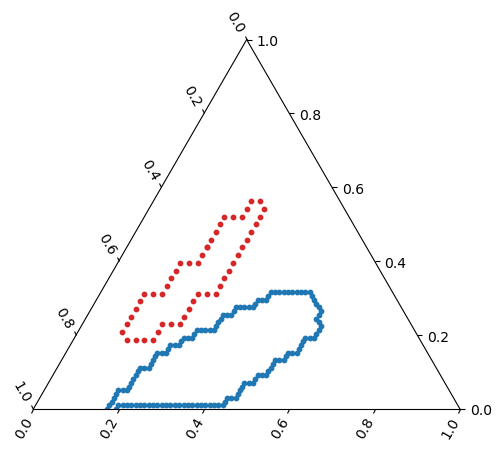

In [20]:
fig, ax = plt.subplots(subplot_kw={"projection":"ternary"})
ax.scatter(
    ref_boundaries["La"][:,0], 
    ref_boundaries["La"][:,1], 
    ref_boundaries["La"][:,2],
    s=10,
    color = "tab:blue"
)
ref_xy = ax.transProjection.transform(ref_boundaries["La"])
ax.scatter(
    query_boundaries["H2"][:,0], 
    query_boundaries["H2"][:,1], 
    query_boundaries["H2"][:,2],
    s=10,
    color = "tab:red"
)
query_xy = ax.transProjection.transform(query_boundaries["H2"])
plt.show()

In [33]:
from scipy.spatial import cKDTree

class LevelSet2DDistance:
    def __init__(self, ref, query):
        self.ref = ref
        self.query = query

    def compute_distance(self):
        """Compute a simple Riemannian-style distance between the level sets."""
        # Build KDTree for correspondence
        tree = cKDTree(self.ref)
        dists, idxs = tree.query(self.query)

        f = self.ref[idxs]
        matched_g = self.query

        # Compute displacement term
        disp = np.linalg.norm(f - matched_g, axis=1)
        E_disp = np.mean(disp ** 2)

        # Compute curvature mismatch (finite differences on curve)
        def curvature(points):
            # approximate curvature for polyline
            pts = np.vstack([points[-1], points, points[0]])
            d1 = np.diff(pts, axis=0)
            d2 = np.diff(d1, axis=0)
            speed = np.linalg.norm(d1[:-1], axis=1) + 1e-12
            cross = d1[:-1, 0] * d2[:, 1] - d1[:-1, 1] * d2[:, 0]
            kappa = cross / (speed ** 3)
            return kappa

        kf = curvature(f)
        kg = curvature(matched_g)
        E_shape = np.mean((kf - kg) ** 2)

        E_total = E_disp + E_shape
        self.distance_value = np.sqrt(E_total)
        return self.distance_value

    def visualize(self, show_correspondence=False):
        plt.figure(figsize=(6, 6))
        plt.plot(self.ref[:, 0], self.ref[:, 1], "b-", label="f")
        plt.plot(self.query[:, 0], self.query[:, 1], "r-", label="g")

        if show_correspondence:
            tree = cKDTree(self.query)
            _, idxs = tree.query(self.ref)
            for p, q in zip(self.ref[::len(self.ref)//50], self.query[idxs][::len(idxs)//50]):
                plt.plot([p[0], q[0]], [p[1], q[1]], "k-", alpha=0.3)

        plt.legend()
        plt.gca().set_aspect("equal")
        plt.title("Levelset contours f=c (blue) and g=c (red)")
        plt.show()

Distance between f and g levelsets: 20.18890970446964


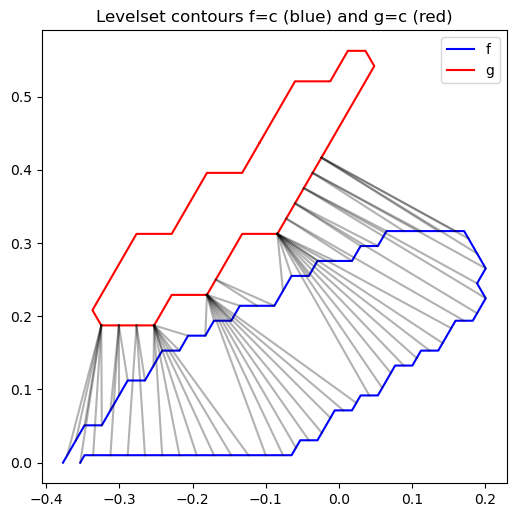

In [34]:
# Instantiate and compute distance
metric = LevelSet2DDistance(ref_xy, query_xy)
dist = metric.compute_distance()
print("Distance between f and g levelsets:", dist)

# Visualize with correspondences
metric.visualize(show_correspondence=True)